In [2]:
import pandas as pd
import random
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network

#### Wygeneruj sieć Erdős-Rényi o N = 100 i p = 0.05

In [3]:
N = 100
p = 0.05
gh = nx.erdos_renyi_graph(N, p, seed=11)

#### Wylistuj wszystkie wierzchołki i krawędzie

In [4]:
gh.nodes(), gh.edges()

(NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99)),
 EdgeView([(0, 16), (0, 22), (0, 27), (0, 51), (1, 23), (1, 41), (1, 56), (1, 57), (1, 61), (1, 99), (2, 11), (2, 49), (2, 51), (2, 56), (2, 59), (2, 63), (2, 74), (3, 25), (3, 63), (3, 89), (4, 41), (4, 54), (4, 74), (4, 84), (5, 17), (5, 34), (5, 55), (5, 74), (5, 76), (6, 40), (7, 34), (8, 9), (8, 33), (8, 43), (8, 61), (8, 99), (9, 15), (9, 60), (9, 67), (10, 34), (10, 45), (10, 57), (11, 29), (11, 39), (11, 40), (11, 97), (12, 24), (12, 56), (12, 63), (12, 77), (12, 96), (13, 17), (13, 25), (13, 39), (13, 72), (13, 86), (13, 97), (14, 15), (14, 35), (14, 36), (14, 73), (14, 84), (15, 2

#### Oblicz stopień (degree) każdego węzła a następnie stwórz histogram stopni węzłów,

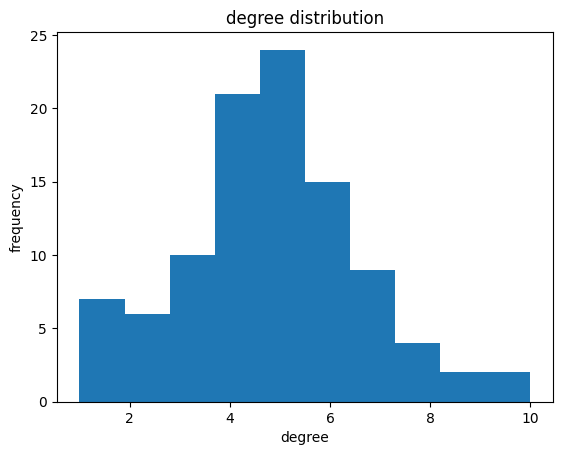

In [6]:
node_degrees = dict(gh.degree())
plt.Figure(figsize=(4, 4))
plt.hist(node_degrees.values(), bins=10)
plt.xlabel("degree")
plt.ylabel("frequency")
plt.title("degree distribution")
plt.show()

#### Przygotuj dataframe oraz jego opis statystyczny z wykorzystaniem funkcji describe. DataFrame powinien zawierać metryki obliczone dla wygenerowanej sieci losowej, przy czym

In [7]:
betweenness = nx.betweenness_centrality(gh)
closness = nx.closeness_centrality(gh)
clustering = nx.clustering(gh)
page_rank = nx.pagerank(gh)

if nx.is_connected(gh):
    avg_path = nx.average_shortest_path_length(gh)
    diameter = nx.diameter(gh)
else:
    largest_cc = max(nx.connected_components(gh), key=len)
    subgraph = gh.subgraph(largest_cc)
    avg_path = nx.average_shortest_path_length(subgraph)
    diameter = nx.diameter(subgraph)

num_components = nx.number_connected_components(gh)

In [10]:
df = pd.DataFrame(
    {
        "Betweenness": pd.Series(betweenness),
        "Closeness": pd.Series(closness),
        "Clustering_Coeff": pd.Series(clustering),
        "PageRank": pd.Series(page_rank),
        "Avg_Shortest_Path": avg_path,
        "Diameter": diameter,
        "Num_Components": num_components,
    }
)

In [11]:
df.head(10)

,Betweenness,Closeness,Clustering_Coeff,PageRank,Avg_Shortest_Path,Diameter,Num_Components
0,0.023029,0.306502,0.000000,0.009317,3.134747,6,1
1,0.023747,0.347368,0.066667,0.011761,3.134747,6,1
2,0.042777,0.354839,0.047619,0.013833,3.134747,6,1
3,0.003801,0.293769,0.333333,0.007099,3.134747,6,1
4,0.026671,0.295522,0.000000,0.010051,3.134747,6,1
5,0.039347,0.356115,0.000000,0.010598,3.134747,6,1
6,0.000000,0.277311,0.000000,0.003190,3.134747,6,1
7,0.000000,0.279661,0.000000,0.003228,3.134747,6,1
8,0.013409,0.319355,0.100000,0.009931,3.134747,6,1
9,0.007892,0.310345,0.000000,0.008267,3.134747,6,1


In [12]:
df.describe().style.format("{:.6f}")

,Betweenness,Closeness,Clustering_Coeff,PageRank,Avg_Shortest_Path,Diameter,Num_Components
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.021783,0.322898,0.055913,0.010000,3.134747,6.000000,1.000000
std,0.017552,0.034306,0.085837,0.003438,0.000000,0.000000,0.000000
min,0.000000,0.228637,0.000000,0.003190,3.134747,6.000000,1.000000
25%,0.008574,0.307215,0.000000,0.008222,3.134747,6.000000,1.000000
50%,0.019181,0.325658,0.000000,0.010156,3.134747,6.000000,1.000000
75%,0.030080,0.340499,0.100000,0.011927,3.134747,6.000000,1.000000
max,0.082039,0.392857,0.333333,0.020334,3.134747,6.000000,1.000000


#### Ile jest komponentów (connected components) w grafie,

In [13]:
nx.number_connected_components(gh)

1

#### Zwizualizuj graf w taki sposób, aby rozmiar węzłów odpowiadał mierze PageRank

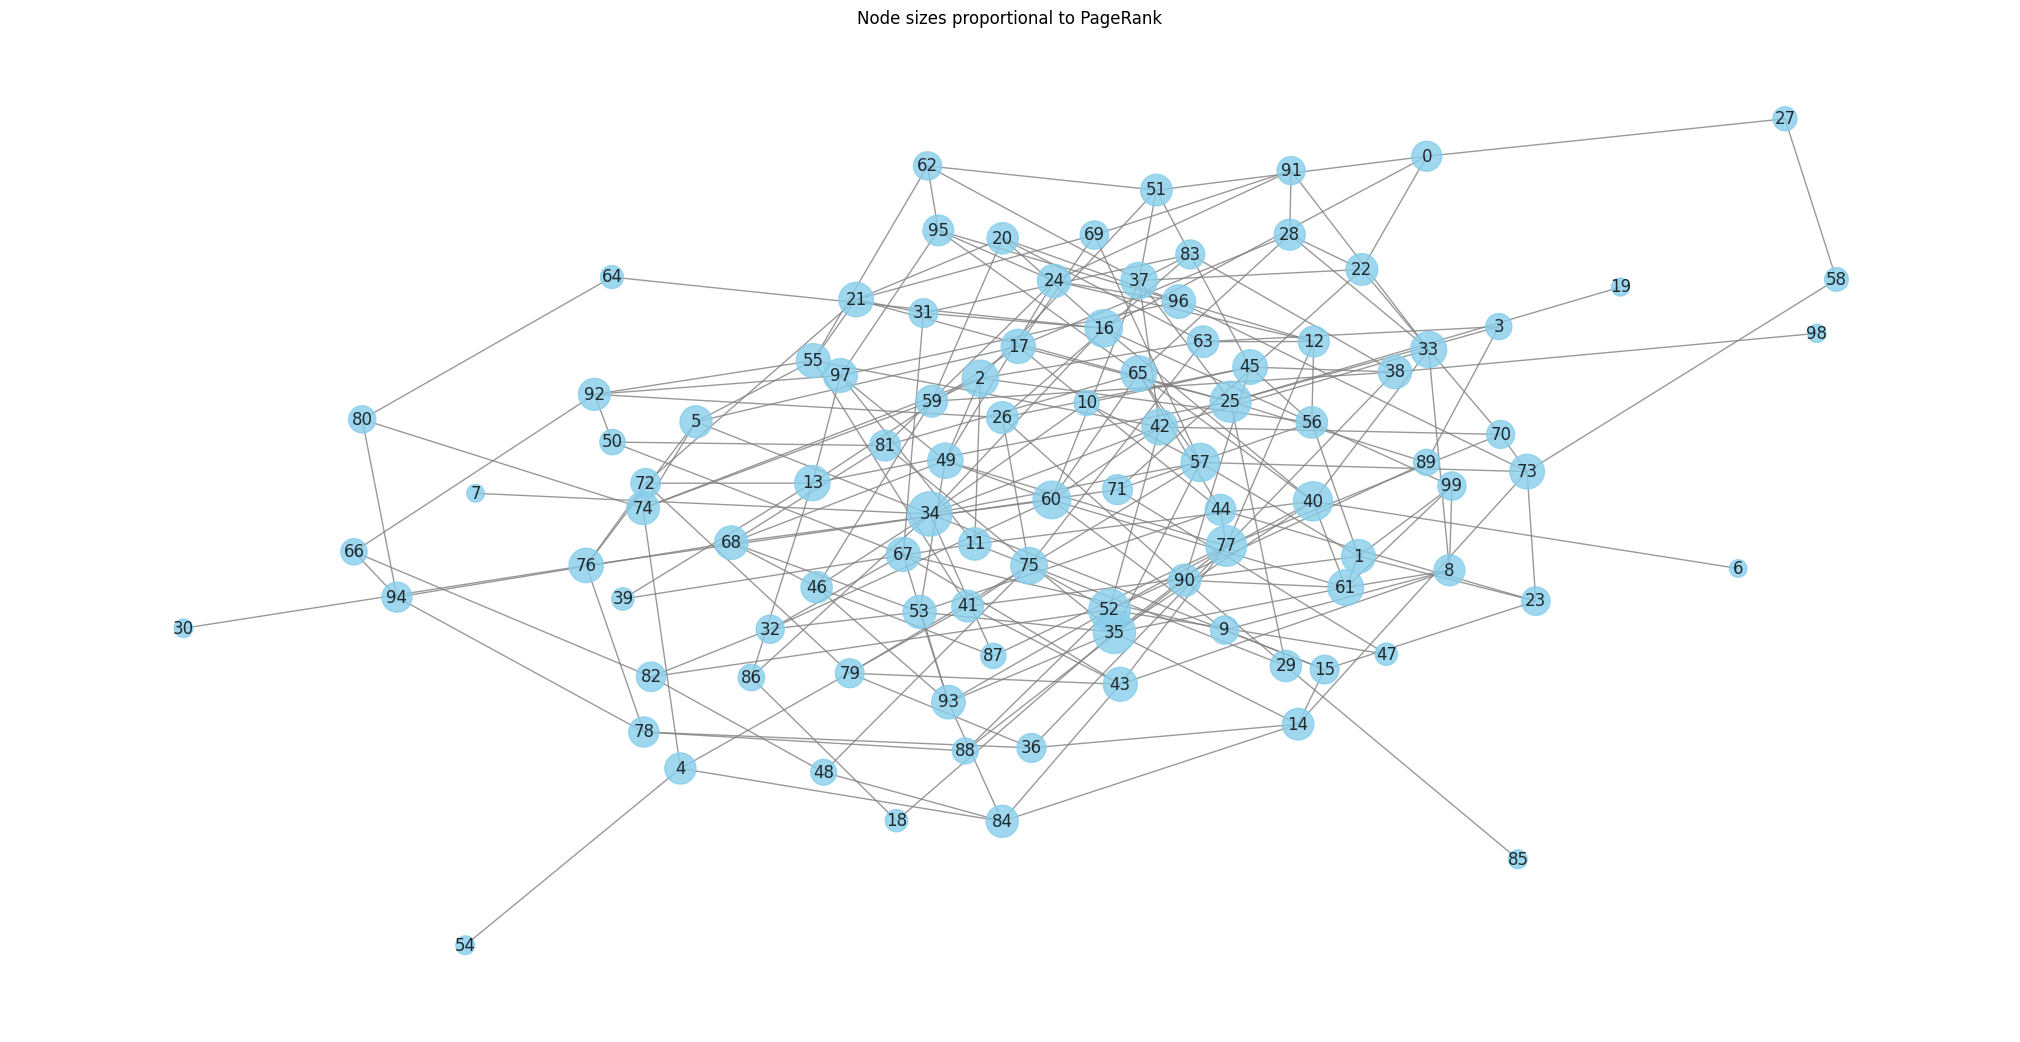

In [22]:
pagerank = nx.pagerank(gh)


sizes = [v * 50000 for v in pagerank.values()]

plt.figure(figsize=(20, 10))
pos = nx.spring_layout(gh, seed=42)

nx.draw(
    gh,
    pos,
    node_size=sizes,
    node_color="skyblue",
    with_labels=True,
    edge_color="gray",
    alpha=0.8,
)

plt.title("Node sizes proportional to PageRank")
plt.show()

___

#### Wygeneruj graf wedle modelu Barabási-Albert z N = 1000 i m0 = m = 3

In [23]:
N, m = 1000, 3
ba = nx.barabasi_albert_graph(N, m, seed=11)

#### Zwizualizuj graf layoutem Kamada-Kawai

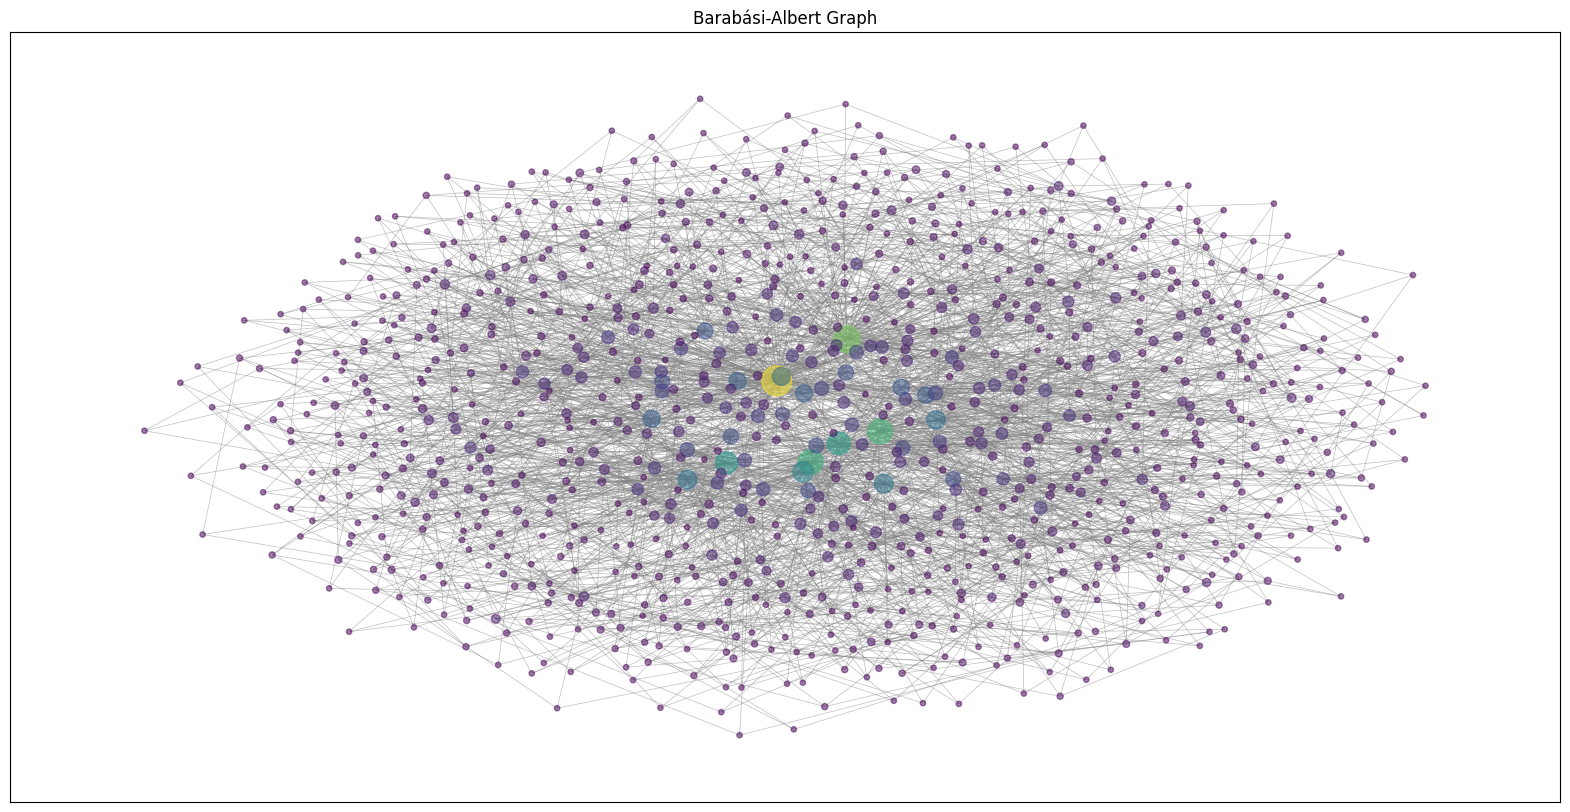

In [32]:
plt.figure(figsize=(20, 10))

degrees = dict(ba.degree())
sizes = [v * 5 for v in degrees.values()]
colors = [v for v in degrees.values()]
pos = nx.kamada_kawai_layout(ba)


nx.draw_networkx_nodes(
    ba,
    pos,
    node_size=sizes,
    node_color=colors,
    alpha=0.5,
)

nx.draw_networkx_edges(ba, pos, edge_color="gray", alpha=0.5,     width=0.5,
)

plt.title("Barabási-Albert Graph")
plt.show()

#### Znajdź najbardziej centralny węzeł według miary pośrednictwa (be-tweenness), jaki ma numer?

In [35]:
betweenness = nx.betweenness_centrality(ba)

most_central = max(betweenness, key=betweenness.get)
print(f"most central node: {most_central} with betweenness: {betweenness[most_central]}")

most central node: 2 with betweenness: 0.17526855642147443


#### Jaka jest średnica grafu?

In [36]:
diameter = nx.diameter(ba)
print(f"diameter of the graph: {diameter}")

diameter of the graph: 6


### Jakie różnice widzisz pomiędzy grafem Barabási-Albert i Erdős-Rényi.

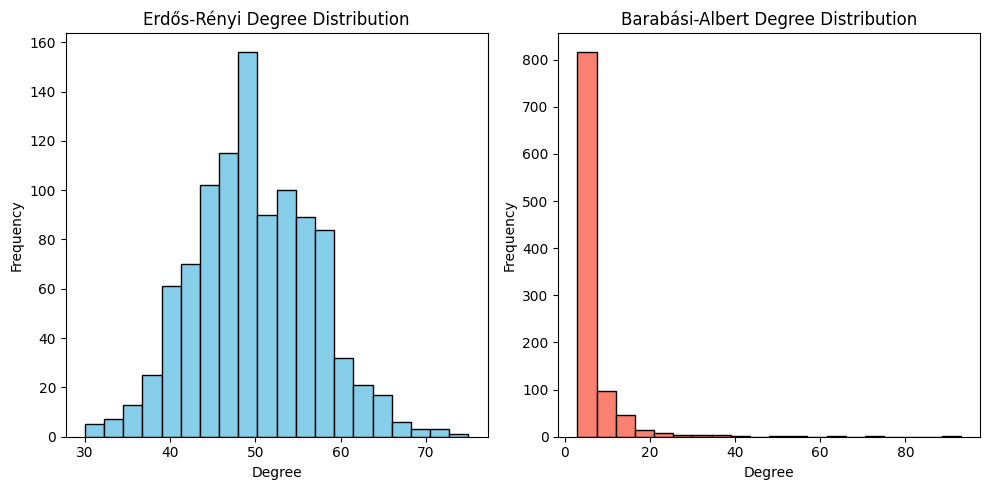

In [37]:
fig, ax = plt.subplots(1, 2,figsize=(10, 5))

er = nx.erdos_renyi_graph(N, p, seed=11)
ba = nx.barabasi_albert_graph(N, m, seed=11)

degrees_er = dict(er.degree())
degrees_ba = dict(ba.degree())

ax[0].hist(degrees_er.values(), bins=20, color="skyblue", edgecolor="black")
ax[0].set_title("Erdős-Rényi Degree Distribution")
ax[0].set_xlabel("Degree")
ax[0].set_ylabel("Frequency")

ax[1].hist(degrees_ba.values(), bins=20, color="salmon", edgecolor="black")
ax[1].set_title("Barabási-Albert Degree Distribution")
ax[1].set_xlabel("Degree")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()



____

In [38]:
g = nx.read_edgelist(
    "ia-radoslaw-email.edges.csv",
    delimiter=",",
    nodetype=int,
    create_using=nx.MultiDiGraph(),
)

In [39]:
f"Number of nodes: {len(g.nodes())}, Number of edges: {len(g.edges())}"

'Number of nodes: 167, Number of edges: 82927'

In [40]:
g.remove_edges_from(nx.selfloop_edges(g))
g = nx.Graph(g)

In [41]:
f"Number of nodes: {len(g.nodes())}, Number of edges: {len(g.edges())}"

'Number of nodes: 167, Number of edges: 3250'

Text(0, 0.5, 'Frequency')

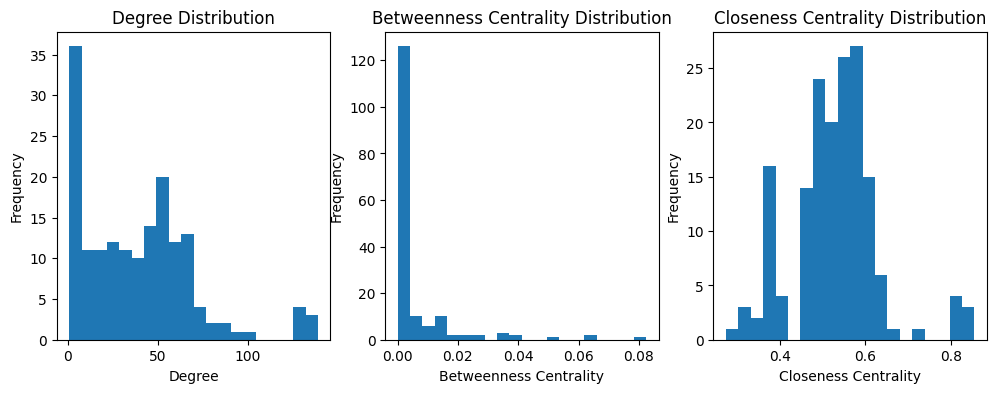

In [40]:
degrees = dict(g.degree())
betweenness = dict(nx.betweenness_centrality(g))
closeness = dict(nx.closeness_centrality(g))

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].hist(degrees.values(), bins=20)
ax[0].set_title("Degree Distribution")
ax[0].set_xlabel("Degree")
ax[0].set_ylabel("Frequency")

ax[1].hist(betweenness.values(), bins=20)
ax[1].set_title("Betweenness Centrality Distribution")
ax[1].set_xlabel("Betweenness Centrality")
ax[1].set_ylabel("Frequency")

ax[2].hist(closeness.values(), bins=20)
ax[2].set_title("Closeness Centrality Distribution")
ax[2].set_xlabel("Closeness Centrality")
ax[2].set_ylabel("Frequency")

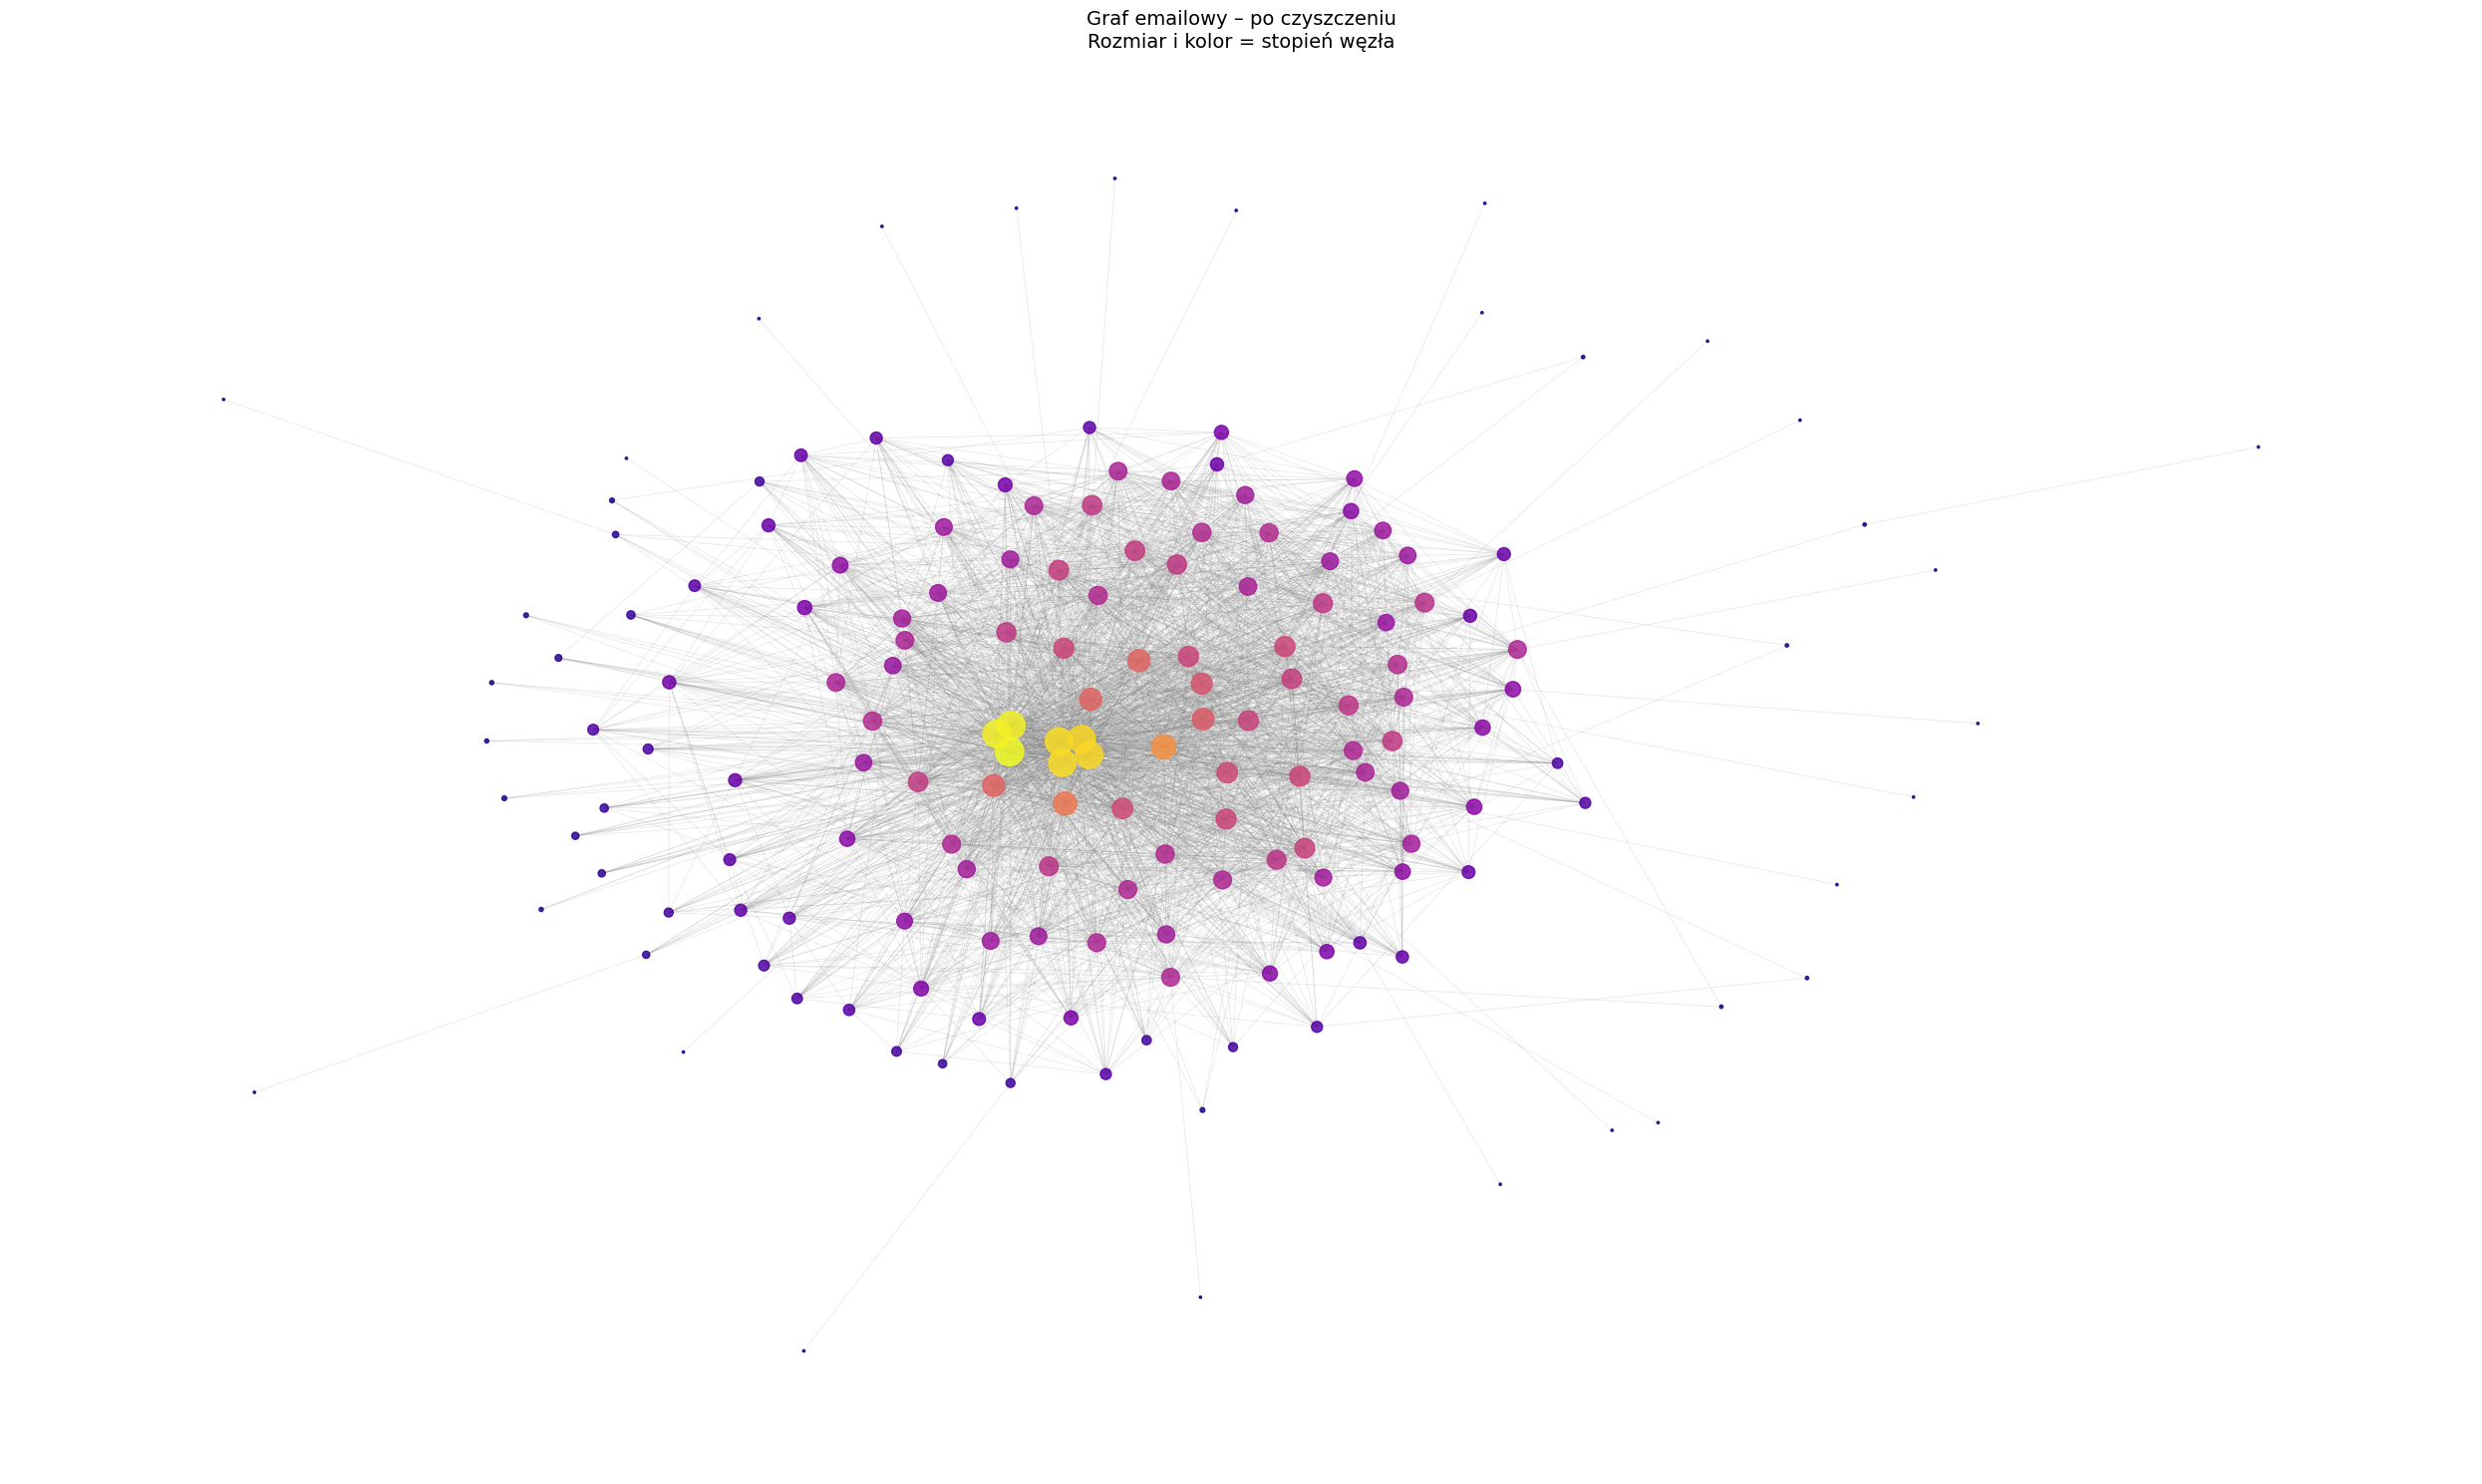

In [42]:
degrees_real = dict(g.degree())

node_sizes_real = [degrees_real[n] * 3 for n in g.nodes()]
node_colors_real = [degrees_real[n] for n in g.nodes()]

plt.figure(figsize=(25, 15))
pos_real = nx.kamada_kawai_layout(g)

nodes_real = nx.draw_networkx_nodes(
    g,
    pos=pos_real,
    node_size=node_sizes_real,
    node_color=node_colors_real,
    cmap=plt.cm.plasma,
    alpha=0.85
)

nx.draw_networkx_edges(
    g,
    pos=pos_real,
    edge_color="gray",
    alpha=0.2,
    width=0.5
)

plt.title("Graf emailowy – po czyszczeniu\nRozmiar i kolor = stopień węzła", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

In [41]:
deg_rank = sorted(degrees, key=degrees.get, reverse=True)
bet_rank = sorted(betweenness, key=betweenness.get, reverse=True)
clo_rank = sorted(closeness, key=closeness.get, reverse=True)

print("Top degree:", deg_rank[:10])
print("Top betweenness:", bet_rank[:10])
print("Top closeness:", clo_rank[:10])

Top degree: [38, 37, 45, 1, 47, 35, 113, 115, 50, 42]
Top betweenness: [38, 37, 45, 47, 1, 68, 35, 113, 84, 80]
Top closeness: [38, 37, 45, 1, 47, 35, 113, 115, 50, 42]


In [42]:
from scipy.stats import kendalltau

deg_vals = [degrees[n] for n in g.nodes()]
bet_vals = [betweenness[n] for n in g.nodes()]
clo_vals = [closeness[n] for n in g.nodes()]

print("Degree vs Betweenness:", kendalltau(deg_vals, bet_vals))
print("Degree vs Closeness:", kendalltau(deg_vals, clo_vals))
print("Betweenness vs Closeness:", kendalltau(bet_vals, clo_vals))

Degree vs Betweenness: SignificanceResult(statistic=np.float64(0.8042256182614058), pvalue=np.float64(6.874122563216967e-51))
Degree vs Closeness: SignificanceResult(statistic=np.float64(0.950852791382257), pvalue=np.float64(5.182614210404855e-72))
Betweenness vs Closeness: SignificanceResult(statistic=np.float64(0.7839475424697699), pvalue=np.float64(2.1587675953142128e-49))


In [46]:
nx.number_connected_components(g)

1